In [65]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import pathlib  # 객체지향 방식으로 파일 경로를 다룸
import urllib.request # url을 통해 파일 다운로드 기능 제공
import tarfile

def get_dataset_path():
    # 실제 압축이 풀려 있는 경로 설정
    # os.path.join을 사용하여 운영체제에 맞는 경로 구분자(\ 또는 /)를 처리합니다.
    data_dir = os.path.join(os.getcwd(), 'tire_datasets', 'tire_photos')

    # 해당 경로가 실제로 존재하는지 확인
    if os.path.exists(data_dir):
        print(f"데이터셋 경로 확인 완료: {data_dir}")
        return data_dir
    else:
        # 경로가 없을 경우 에러 메시지 출력
        print(f"경고: {data_dir} 경로를 찾을 수 없습니다.")
        return None

# 데이터 경로 할당
data_root = get_dataset_path()

데이터셋 경로 확인 완료: c:\Python310\projects\ydataprofiling\tire_datasets\tire_photos


In [66]:
data_dir = get_dataset_path() # 함수호출
data_dir = pathlib.Path(data_dir)  # 현재작업경로/flower_dataset/flower_photos)을 data_dir 변수에 저장

데이터셋 경로 확인 완료: c:\Python310\projects\ydataprofiling\tire_datasets\tire_photos


In [67]:
# 클래스 및 이미지 개수 확인
# data_dir.glob('*/'): data_dir(pathlib.Path 객체) 아래의 모든 하위 디렉터리를 탐색
# item.is_dir(): 탐색된 항목이 실제로 디렉터리인지 확인하는 조건
classes = sorted([item.name for item in data_dir.glob('*/') if item.is_dir()])  # 리스트 컴프리헨션을 사용하여 각 디렉터리의 이름(예: 'daisy', 'dandelion' 등)만 추출
image_count = len(list(data_dir.glob('*/*.jpg')))
print(f"발견된 클래스: {classes}")
print(f"총 이미지 개수: {image_count}")

발견된 클래스: ['defective', 'good']
총 이미지 개수: 1856


In [68]:
# 각 클래스별 이미지 개수 확인
for class_name in classes:
    class_images = len(list(data_dir.glob(f'{class_name}/*')))
    print(f"{class_name}: {class_images}개 이미지")

defective: 1028개 이미지
good: 828개 이미지


In [69]:
img_height = 180
img_width = 180
batch_size = 32

In [70]:
# 훈련 데이터셋 생성
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(data_dir),
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 1856 files belonging to 2 classes.
Using 1485 files for training.


In [71]:
# 검증 데이터셋 생성
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(data_dir),
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 1856 files belonging to 2 classes.
Using 371 files for validation.


In [72]:
# 클래스 이름 확인
class_names = train_ds.class_names # class_names: 하위 폴더 이름들을 클래스 이름으로 인식
print("클래스:", class_names)
num_classes = len(class_names)

클래스: ['defective', 'good']


In [ ]:
# 데이터셋 성능 최적화
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [74]:
# 데이터 증강 레이어 정의
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2), # 대비 변화 추가
])

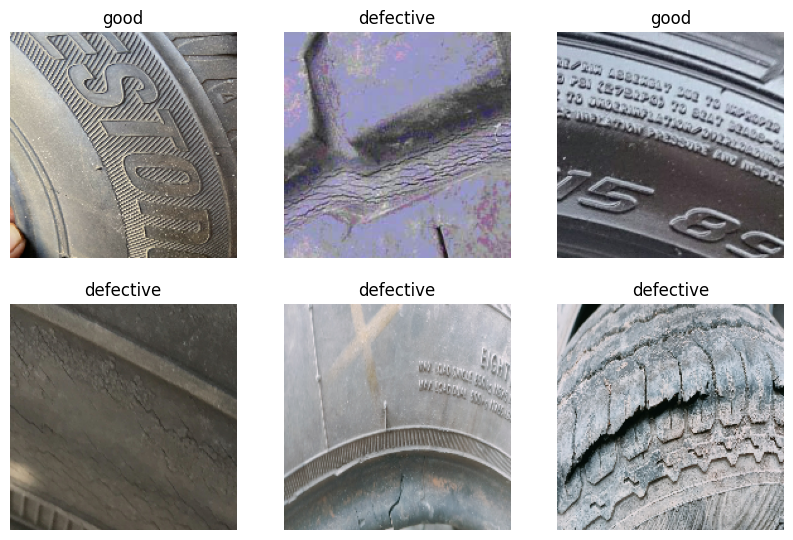

In [89]:
# 샘플 이미지 시각화
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  # 데이터셋에서 첫 번째 배치 하나만 가져옴
    for i in range(6):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))   # astype("uint8"): 픽셀값을 0~255 정수로 변환
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. 입력 크기 설정
IMG_SIZE = 180 

# 2. 모델 로드 (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    
    # 전처리 레이어 (MobileNetV2 전용 전처리: 픽셀 값을 -1 ~ 1 범위로 변환)
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='softmax')
])

# 4. 컴파일
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# 5. 클래스 가중치 부여
class_weight = {0: 2.0, 1: 1.0}

# 6. 모델 학습 실행
history = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=20, 
    class_weight=class_weight
)

C:\Users\human-31\AppData\Local\Temp\ipykernel_11776\538862973.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 531ms/step - accuracy: 0.5778 - loss: 1.3692 - val_accuracy: 0.7385 - val_loss: 0.5142
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 436ms/step - accuracy: 0.7064 - loss: 0.7999 - val_accuracy: 0.7871 - val_loss: 0.4234
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 425ms/step - accuracy: 0.7798 - loss: 0.6144 - val_accuracy: 0.8275 - val_loss: 0.3674
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 426ms/step - accuracy: 0.8054 - loss: 0.5309 - val_accuracy: 0.8518 - val_loss: 0.3171
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 449ms/step - accuracy: 0.8545 - loss: 0.4424 - val_accuracy: 0.8491 - val_loss: 0.3338
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 426ms/step - accuracy: 0.8559 - loss: 0.4160 - val_accuracy: 0.8625 - val_loss: 0.2874
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 426ms/step - accuracy: 0.8727 - loss: 0.3791 - val_accuracy: 0.8625 - val_loss: 0.2916
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 407ms/step - accuracy: 0.8970 - loss: 0.3342 - val_accu

In [77]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,664 (10.49 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,454 (1.25 MB)

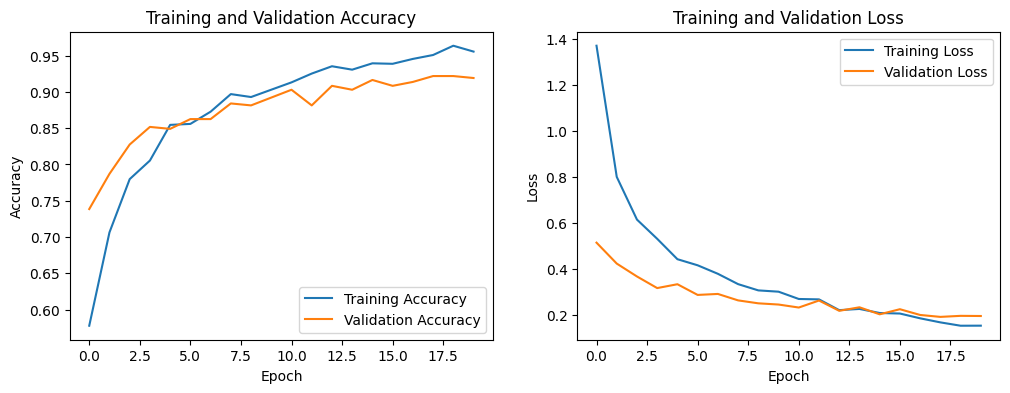

In [78]:

# 학습 결과 시각화
acc = history.history['accuracy']  # 뒤의 history는 학습 과정을 담고 있는 딕셔너리
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [79]:
# 모델 저장
model.save('./model/tire_classification_model.h5')
print("모델이 'tire_classification_model.h5'로 저장되었습니다.")

모델이 'tire_classification_model.h5'로 저장되었습니다.


In [80]:
from tensorflow.keras.models import load_model
import tensorflow as tf

model_path = './model/tire_classification_model.h5'

# preprocess_input 함수를 커스텀 오브젝트로 등록하여 로드
loaded_model = load_model(
    model_path, 
    custom_objects={'preprocess_input': tf.keras.applications.mobilenet_v2.preprocess_input}
)

print("저장된 모델이 성공적으로 로드되었습니다.")

저장된 모델이 성공적으로 로드되었습니다.


In [81]:
# 저장된 모델을 활용한 이미지 예측 함수
def predict_tire_with_loaded_model(img_path, model, class_names):
    """
    이미지 경로와 모델을 입력받아 예측 결과를 출력하고 이미지를 시각화하는 함수.

    Parameters:
        img_path (str): 예측할 이미지 파일 경로.
        model (tf.keras.Model): 저장된 모델.
        class_names (list): 클래스 이름 리스트.
    """
    # 이미지 로드 및 전처리
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(img_height, img_width)  # PIL 이미지 객체
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)  # 이미지를 숫자 배열(numpy 형태)로 변환
    img_array = tf.expand_dims(img_array, 0)  # 배치 차원 추가 : ex. (1, 높이, 너비, 3) 형태의 배치

    # 예측 수행
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    # 예측 결과 출력
    print(
        "이 이미지는 '{}' ({:.2f}% 확률) 입니다."
        .format(class_names[np.argmax(score)], 100 * np.max(score))
    )

    # 이미지 시각화
    plt.imshow(img)
    plt.axis('off')
    plt.show()


In [82]:
# 테스트 이미지 경로
#test_image_path = './tire_datasets/tire_photos/good/good (50).jpg'
#test_image_path = './tire_datasets/tire_photos/defective/defective (50).jpg'
test_image_path = './tire_datasets/tire_photos/defective/defective (30).jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
이 이미지는 'defective' (73.09% 확률) 입니다.


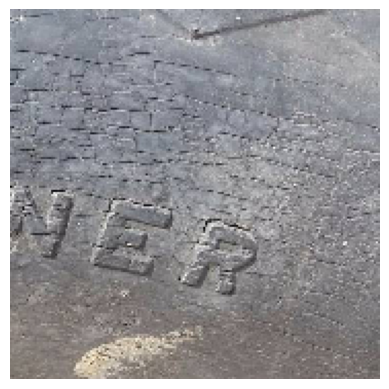

In [83]:
# 예측 실행
predict_tire_with_loaded_model(test_image_path, loaded_model, class_names)

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [85]:
import tensorflow as tf
import os

# 1. 경로 설정
data_root = os.path.join(os.getcwd(), 'tire_datasets', 'tire_photos')

# 2. 이미지 데이터셋 생성
img_height = 180 
img_width = 180
batch_size = 32

# 검증
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_root,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = test_ds.class_names
print(f"클래스 이름: {class_names}")

Found 1856 files belonging to 2 classes.
Using 371 files for validation.
클래스 이름: ['defective', 'good']


In [86]:
# 1. 테스트 데이터셋의 실제 레이블과 모델의 예측값 수집
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# 2. 혼동 행렬 생성
cm = confusion_matrix(y_true, y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step


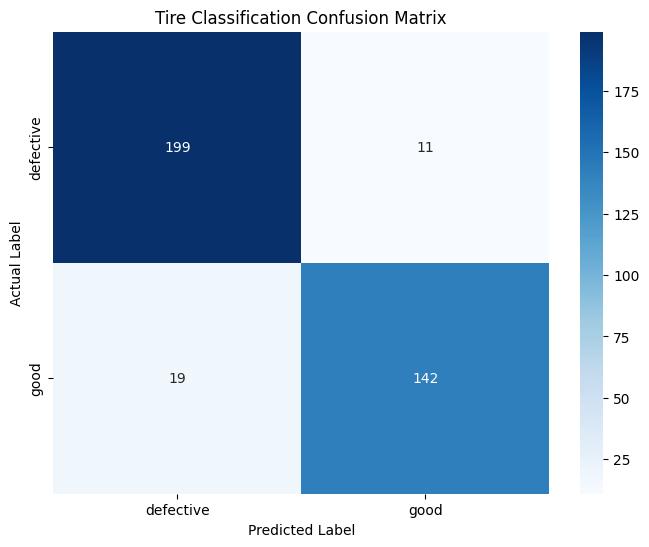

In [87]:
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Tire Classification Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_confusion_matrix(cm, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


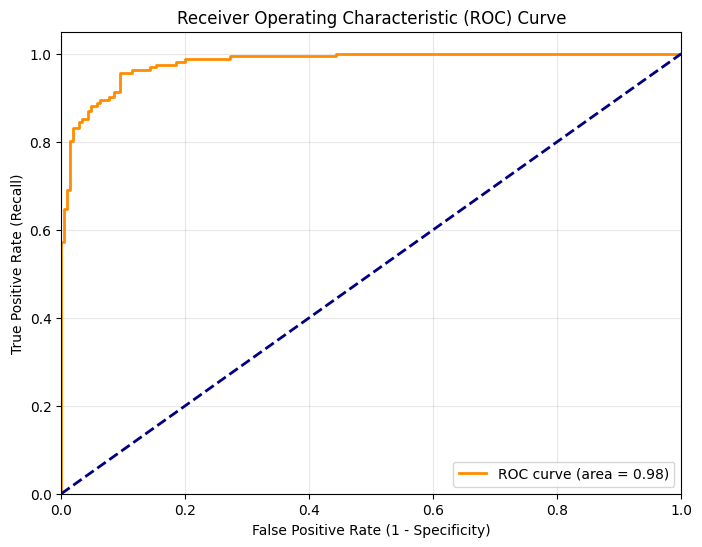

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. 예측 확률값 수집
y_true = []
y_probs = [] # 각 샘플이 'good'(또는 설정한 양성 클래스)일 확률

for images, labels in test_ds:
    predictions = loaded_model.predict(images)
    y_true.extend(labels.numpy())
    # 2진 분류라면 보통 인덱스 1(예: 'good')에 해당하는 확률을 사용합니다.
    # class_names의 순서를 확인하세요 (0: defective, 1: good 가정)
    y_probs.extend(predictions[:, 1]) 

# 2. ROC 곡선 요소 계산
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# 3. 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 기준선 (랜덤 예측)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()